In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
file_path=r"C:\Users\Admin\Desktop\PROJECTS\IITG- SQL project\Dataset.csv"
df=pd.read_csv(file_path)

In [4]:
df.shape
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   str    
 3   Item Purchased          3900 non-null   str    
 4   Category                3900 non-null   str    
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   str    
 7   Size                    3900 non-null   str    
 8   Color                   3900 non-null   str    
 9   Season                  3900 non-null   str    
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   str    
 12  Shipping Type           3900 non-null   str    
 13  Discount Applied        3900 non-null   str    
 14  Promo Code Used         3900 non-null   str    
 15

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

In [5]:
df.describe()

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [6]:
#CLEANING DATA- FLAW IDENTIFIED: biweekly and fortnightly + quarterly and 3months is seaparte, shoudl combine them
#37 null values in review ratings
dfc=df.copy()
dfc["Frequency of Purchases"]=dfc["Frequency of Purchases"].replace("Fortnightly","Bi-Weekly")
dfc["Frequency of Purchases"]=dfc["Frequency of Purchases"].replace("Every 3 Months", "Quarterly")

In [7]:
#verifying changes
dfc["Frequency of Purchases"].value_counts()

Frequency of Purchases
Quarterly    1147
Bi-Weekly    1089
Annually      572
Monthly       553
Weekly        539
Name: count, dtype: int64

sorted entries now.

In [8]:
dfc.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Bi-Weekly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Bi-Weekly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [9]:
sns.set_theme(style="whitegrid",palette="muted")
freq_order=['Weekly','Bi-Weekly','Monthly','Quarterly','Annually']
def save_plot(name):
    plt.savefig(f"{name}.png",dpi=150,bbox_inches='tight')
    plt.show()
    plt.close()
    print(f"{name}.png Saved")

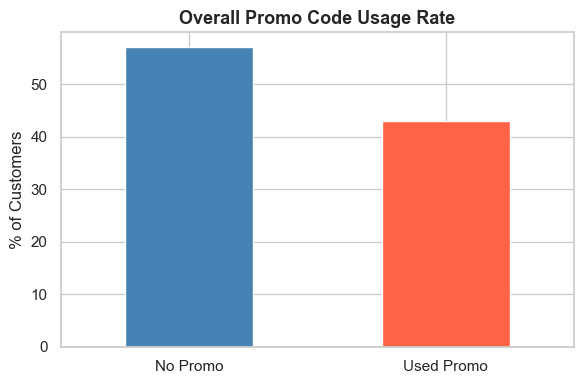

01a_overall_promo_rate.png Saved


In [10]:
#1.1 Overall Promo vs No-Promo Rate
promo_overall=dfc["Promo Code Used"].value_counts(normalize=True)*100

promo_overall.plot(kind='bar', figsize=(6,4), color=['steelblue','tomato'], edgecolor='white')
plt.title("Overall Promo Code Usage Rate", fontsize=13, fontweight='bold')
plt.ylabel("% of Customers")
plt.xlabel("")
plt.xticks(ticks=[0,1],labels=["No Promo","Used Promo"],rotation=0)
plt.tight_layout()
save_plot("01a_overall_promo_rate")

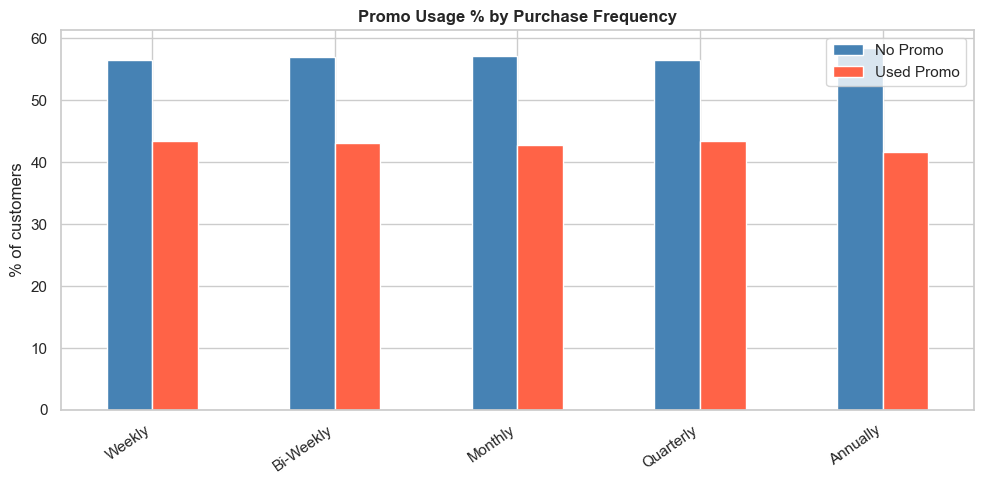

01b_promo_by_frequency.png Saved


In [11]:
#1.2 Promo Usage % by Purchase Frequency
ct_12=pd.crosstab(dfc["Frequency of Purchases"], dfc['Promo Code Used'], normalize='index')*100
ct_12=ct_12.reindex([f for f in freq_order if f in ct_12.index])
ct_12.plot(kind='bar', figsize=(10,5), color=['steelblue','tomato'], edgecolor='white')
plt.title("Promo Usage % by Purchase Frequency", fontsize=12, fontweight='bold')
plt.ylabel("% of customers")
plt.xlabel("")
plt.xticks(rotation=35,ha='right')
plt.legend(["No Promo","Used Promo"])
plt.tight_layout()
save_plot("01b_promo_by_frequency")


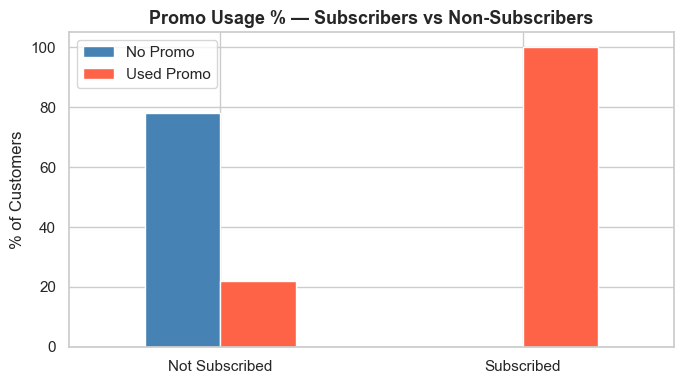

01c_promo_by_subscription.png Saved


In [12]:
#1.3 Promo Usage % by subscription status
ct_13=pd.crosstab(dfc["Subscription Status"], dfc["Promo Code Used"], normalize='index')*100
ct_13.plot(kind='bar', figsize=(7,4), color=['steelblue','tomato'], edgecolor='white')
plt.title("Promo Usage % — Subscribers vs Non-Subscribers", fontsize=13, fontweight='bold')
plt.ylabel("% of Customers")
plt.xlabel("")
plt.xticks(ticks=[0, 1], labels=["Not Subscribed", "Subscribed"], rotation=0)
plt.legend(["No Promo", "Used Promo"])
plt.tight_layout()
save_plot("01c_promo_by_subscription")

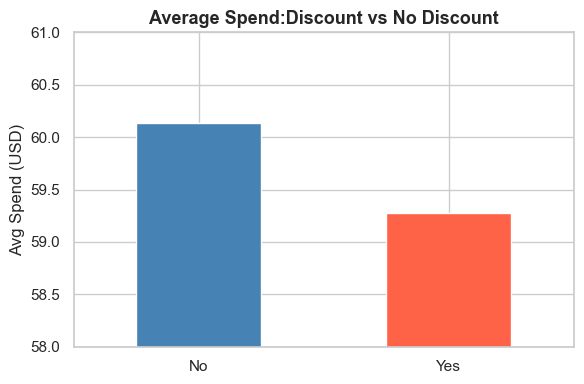

01d_spend_by_discount.png Saved


In [13]:
#1.4 Avg Spend: Discount vs No Discount
spend_14=dfc.groupby("Discount Applied")["Purchase Amount (USD)"].mean()
spend_14.plot(kind='bar', figsize=(6,4), color=['steelblue','tomato'], edgecolor='white')
plt.title("Average Spend:Discount vs No Discount", fontsize=13, fontweight='bold')
plt.ylabel("Avg Spend (USD)")
plt.xlabel("")
plt.xticks([0,1], label=["No Discount Applied", "Discount Applied"], rotation=0)
plt.ylim(58,61)
plt.tight_layout()
save_plot("01d_spend_by_discount")


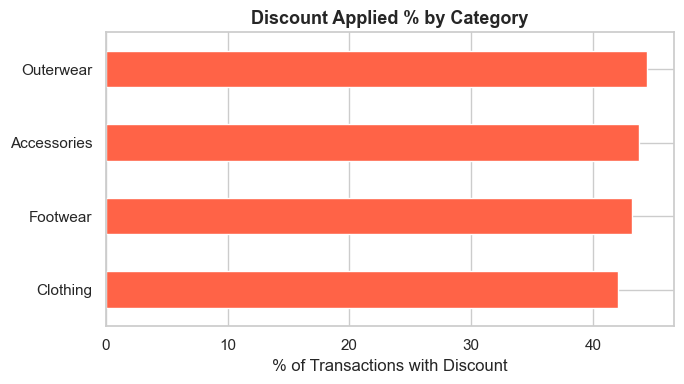

01e_discount_by_category.png Saved


In [14]:
#1.5 Discoumt Rate by Category
ct_15 = pd.crosstab(dfc["Category"], dfc["Discount Applied"],
                    normalize='index') * 100

ct_15["Yes"].sort_values().plot(kind='barh', figsize=(7, 4), color='tomato', edgecolor='white')
plt.title("Discount Applied % by Category", fontsize=13, fontweight='bold')
plt.xlabel("% of Transactions with Discount")
plt.ylabel("")
plt.tight_layout()
save_plot("01e_discount_by_category")

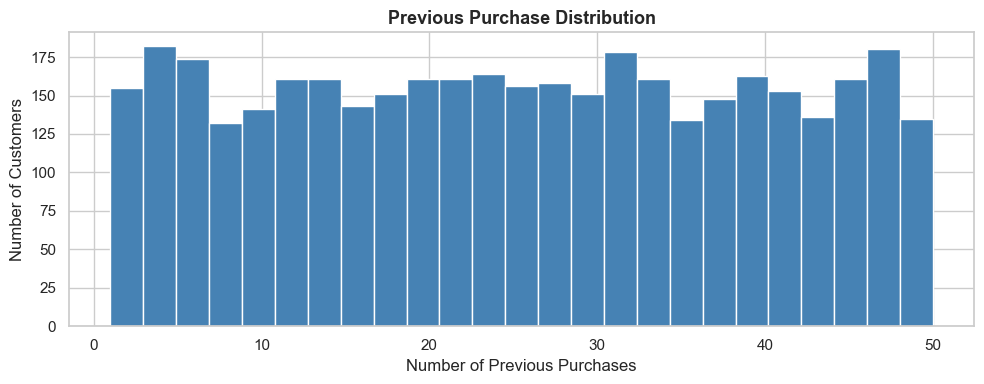

02a_purchase_distribution.png Saved


In [15]:
#2.1 Previous Purchase Distribution
plt.figure(figsize=(10, 4))
plt.hist(dfc["Previous Purchases"], bins=25, color='steelblue', edgecolor='white')
plt.title("Previous Purchase Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Number of Previous Purchases")
plt.ylabel("Number of Customers")
plt.tight_layout()
save_plot("02a_purchase_distribution")

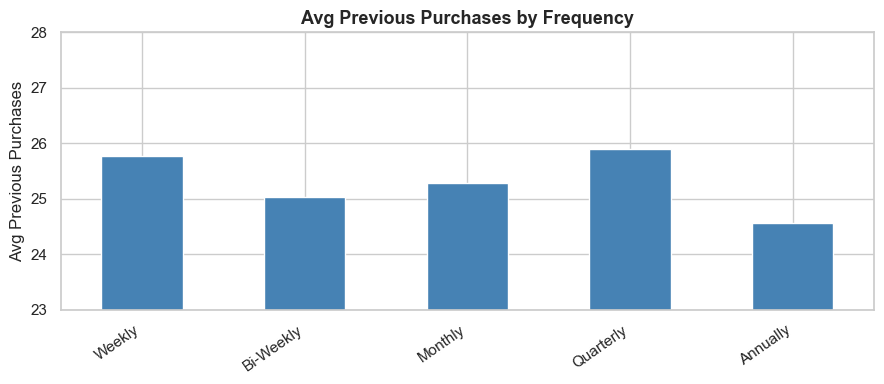

02b_prev_purchases_by_frequency.png Saved


In [16]:
#  BLOCK 2.2 — Avg Previous Purchases by Frequency
avg_22 = dfc.groupby("Frequency of Purchases")["Previous Purchases"].mean()
avg_22 = avg_22.reindex([f for f in freq_order if f in avg_22.index])

avg_22.plot(kind='bar', figsize=(9, 4), color='steelblue', edgecolor='white')
plt.title("Avg Previous Purchases by Frequency", fontsize=13, fontweight='bold')
plt.ylabel("Avg Previous Purchases")
plt.xlabel("")
plt.xticks(rotation=35, ha='right')
plt.ylim(23, 28)  # zoom in to show variation
plt.tight_layout()
save_plot("02b_prev_purchases_by_frequency")

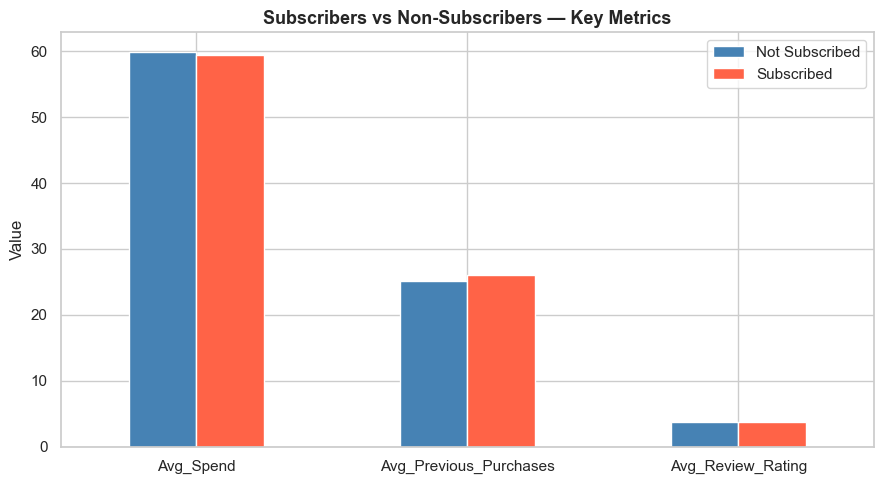

02c_subscriber_comparison.png Saved


In [17]:
# ── BLOCK 2.3 — Subscribers vs Non-Subscribers Comparison ────────────────────
metrics_23 = dfc.groupby("Subscription Status").agg(
    Avg_Spend=("Purchase Amount (USD)", "mean"),
    Avg_Previous_Purchases=("Previous Purchases", "mean"),
    Avg_Review_Rating=("Review Rating", "mean")
).T  # transpose so metrics are rows

metrics_23.plot(kind='bar', figsize=(9, 5), color=['steelblue', 'tomato'], edgecolor='white')
plt.title("Subscribers vs Non-Subscribers — Key Metrics", fontsize=13, fontweight='bold')
plt.ylabel("Value")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(["Not Subscribed", "Subscribed"])
plt.tight_layout()
save_plot("02c_subscriber_comparison")

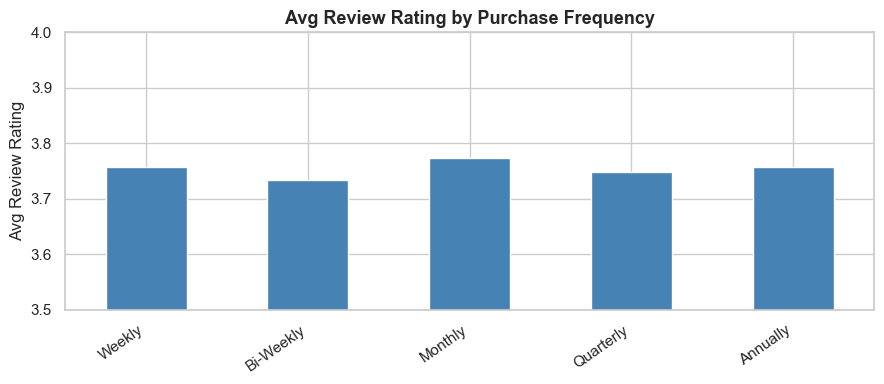

02d_rating_by_frequency.png Saved


In [18]:
# ── BLOCK 2.4 — Avg Review Rating by Frequency ───────────────────────────────
rating_24 = dfc.groupby("Frequency of Purchases")["Review Rating"].mean()
rating_24 = rating_24.reindex([f for f in freq_order if f in rating_24.index])

rating_24.plot(kind='bar', figsize=(9, 4), color='steelblue', edgecolor='white')
plt.title("Avg Review Rating by Purchase Frequency", fontsize=13, fontweight='bold')
plt.ylabel("Avg Review Rating")
plt.xlabel("")
plt.xticks(rotation=35, ha='right')
plt.ylim(3.5, 4.0)  # zoom in to show variation
plt.tight_layout()
save_plot("02d_rating_by_frequency")

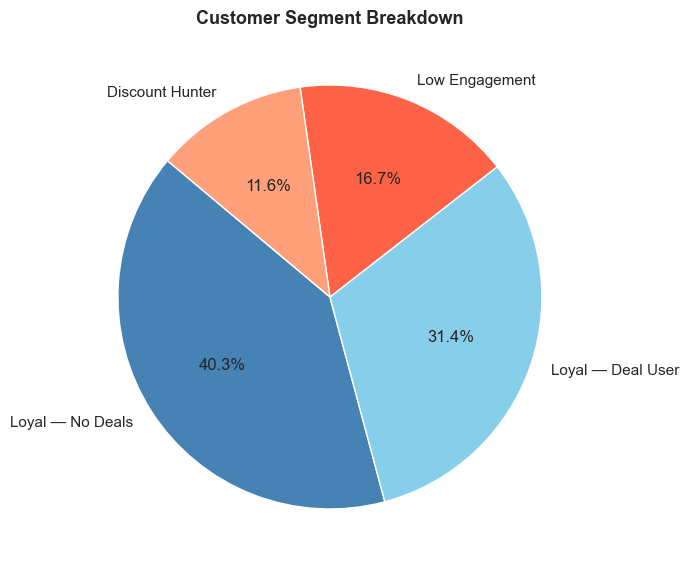

02e_segment_breakdown.png Saved


In [19]:
# ── BLOCK 2.5 — Customer Segment Breakdown ───────────────────────────────────
# Build segments
dfc["Segment"] = "Low Engagement"
dfc.loc[(dfc["Previous Purchases"] >= 15) & 
        (dfc["Promo Code Used"] == "No") & 
        (dfc["Discount Applied"] == "No"), "Segment"] = "Loyal — No Deals"
dfc.loc[(dfc["Previous Purchases"] >= 15) & 
        ((dfc["Promo Code Used"] == "Yes") | 
         (dfc["Discount Applied"] == "Yes")), "Segment"] = "Loyal — Deal User"
dfc.loc[(dfc["Previous Purchases"] < 15) & 
        ((dfc["Promo Code Used"] == "Yes") | 
         (dfc["Discount Applied"] == "Yes")), "Segment"] = "Discount Hunter"

seg_counts = dfc["Segment"].value_counts()

seg_counts.plot(kind='pie', figsize=(7, 7), autopct='%1.1f%%',
                colors=['steelblue', 'skyblue', 'tomato', 'lightsalmon'],
                startangle=140, wedgeprops=dict(edgecolor='white'))
plt.title("Customer Segment Breakdown", fontsize=13, fontweight='bold')
plt.ylabel("")
plt.tight_layout()
save_plot("02e_segment_breakdown")

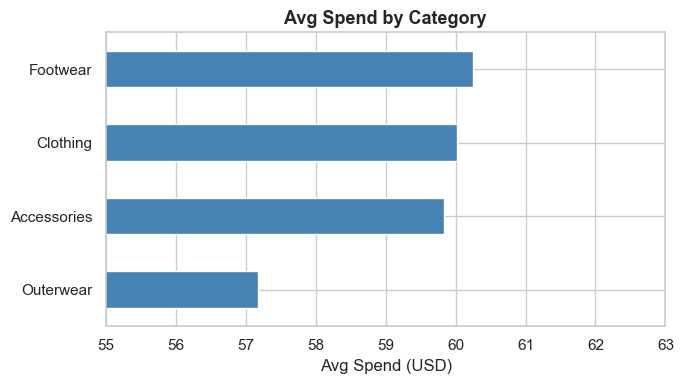

03a_spend_by_category.png Saved


In [20]:
# ── BLOCK 3.1 — Avg Spend by Category ────────────────────────────────────────
spend_31 = dfc.groupby("Category")["Purchase Amount (USD)"].mean().sort_values()

spend_31.plot(kind='barh', figsize=(7, 4), color='steelblue', edgecolor='white')
plt.title("Avg Spend by Category", fontsize=13, fontweight='bold')
plt.xlabel("Avg Spend (USD)")
plt.ylabel("")
plt.xlim(55, 63)
plt.tight_layout()
save_plot("03a_spend_by_category")

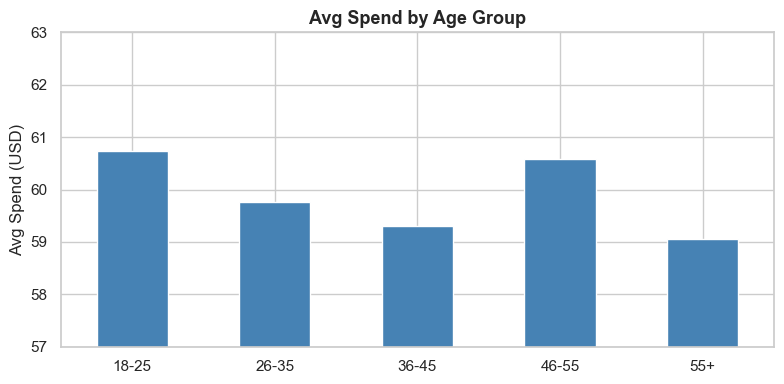

03b_spend_by_age.png Saved


In [21]:
# ── BLOCK 3.2 — Avg Spend by Age Group ───────────────────────────────────────
bins = [18, 25, 35, 45, 55, 70]
labels = ['18-25', '26-35', '36-45', '46-55', '55+']
dfc["Age Group"] = pd.cut(dfc["Age"], bins=bins, labels=labels, right=True)

spend_32 = dfc.groupby("Age Group", observed=True)["Purchase Amount (USD)"].mean()

spend_32.plot(kind='bar', figsize=(8, 4), color='steelblue', edgecolor='white')
plt.title("Avg Spend by Age Group", fontsize=13, fontweight='bold')
plt.ylabel("Avg Spend (USD)")
plt.xlabel("")
plt.xticks(rotation=0)
plt.ylim(57, 63)
plt.tight_layout()
save_plot("03b_spend_by_age")

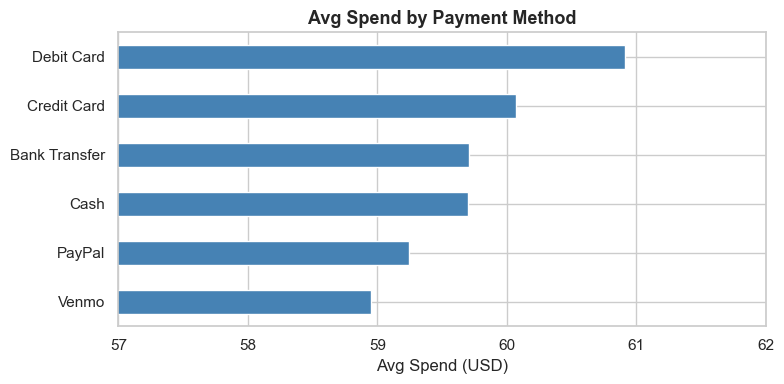

03c_spend_by_payment.png Saved


In [22]:
# ── BLOCK 3.3 — Avg Spend by Payment Method ──────────────────────────────────
spend_33 = dfc.groupby("Payment Method")["Purchase Amount (USD)"].mean().sort_values()

spend_33.plot(kind='barh', figsize=(8, 4), color='steelblue', edgecolor='white')
plt.title("Avg Spend by Payment Method", fontsize=13, fontweight='bold')
plt.xlabel("Avg Spend (USD)")
plt.ylabel("")
plt.xlim(57, 62)
plt.tight_layout()
save_plot("03c_spend_by_payment")

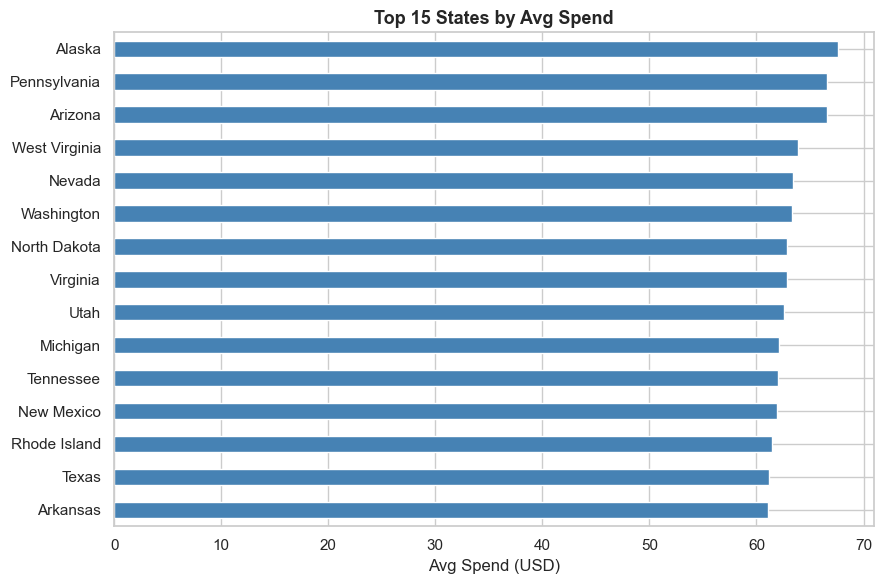

03d_top15_states_spend.png Saved


In [23]:
# ── BLOCK 3.4 — Top 15 States by Avg Spend ───────────────────────────────────
spend_34 = dfc.groupby("Location")["Purchase Amount (USD)"].mean().sort_values(ascending=False).head(15)

spend_34.sort_values().plot(kind='barh', figsize=(9, 6), color='steelblue', edgecolor='white')
plt.title("Top 15 States by Avg Spend", fontsize=13, fontweight='bold')
plt.xlabel("Avg Spend (USD)")
plt.ylabel("")
plt.tight_layout()
save_plot("03d_top15_states_spend")

In [24]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


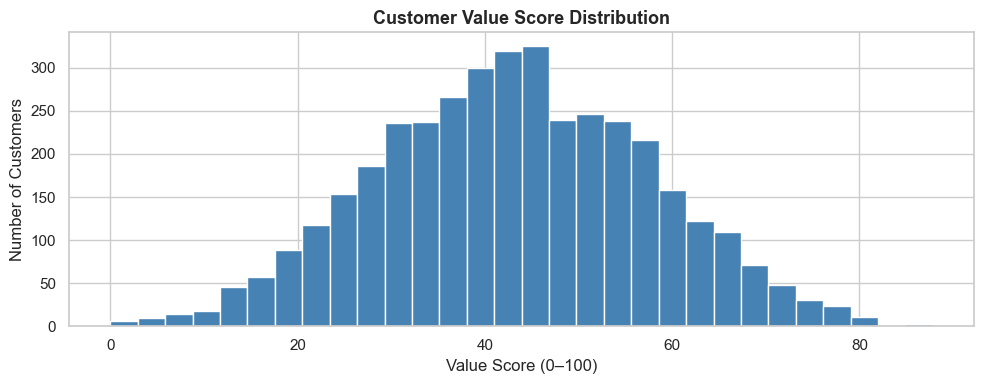

04a_value_score_distribution.png Saved


In [25]:
# ── BLOCK 4.1 — Value Score Distribution ─────────────────────────────────────
# Build value score first
from sklearn.preprocessing import MinMaxScaler

dfc_score = dfc.copy()
dfc_score["Review Rating"] = dfc_score["Review Rating"].fillna(dfc_score["Review Rating"].median())

freq_map = {'Weekly': 5, 'Bi-Weekly': 4, 'Monthly': 3, 'Quarterly': 2, 'Annually': 1}
dfc_score["Freq Score"] = dfc_score["Frequency of Purchases"].map(freq_map)

scaler = MinMaxScaler()
cols_to_scale = ["Purchase Amount (USD)", "Previous Purchases", "Freq Score", "Review Rating"]
dfc_score[cols_to_scale] = scaler.fit_transform(dfc_score[cols_to_scale])

dfc_score["Promo Penalty"] = dfc_score["Promo Code Used"].map({"Yes": 1, "No": 0})
dfc_score["Discount Penalty"] = dfc_score["Discount Applied"].map({"Yes": 1, "No": 0})
dfc_score["Sub Bonus"] = dfc_score["Subscription Status"].map({"Yes": 1, "No": 0})

dfc_score["Value Score"] = (
    dfc_score["Purchase Amount (USD)"] * 25 +
    dfc_score["Previous Purchases"] * 30 +
    dfc_score["Freq Score"] * 20 +
    dfc_score["Review Rating"] * 15 +
    dfc_score["Sub Bonus"] * 10 -
    dfc_score["Promo Penalty"] * 5 -
    dfc_score["Discount Penalty"] * 5
).clip(0, 100)

# Plot distribution
plt.figure(figsize=(10, 4))
plt.hist(dfc_score["Value Score"], bins=30, color='steelblue', edgecolor='white')
plt.title("Customer Value Score Distribution", fontsize=13, fontweight='bold')
plt.xlabel("Value Score (0–100)")
plt.ylabel("Number of Customers")
plt.tight_layout()
save_plot("04a_value_score_distribution")

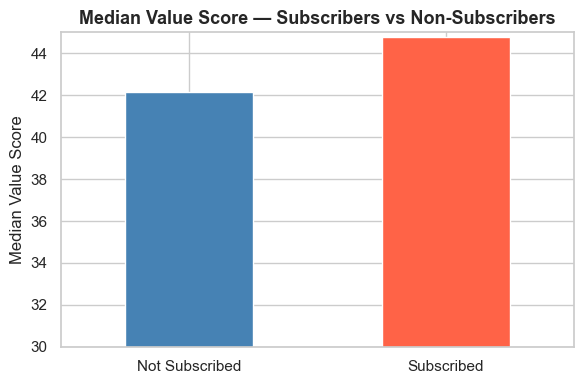

04b_score_by_subscription.png Saved


In [26]:
# ── BLOCK 4.2 — Median Score by Subscription Status ──────────────────────────
score_42 = dfc_score.groupby("Subscription Status")["Value Score"].median()

score_42.plot(kind='bar', figsize=(6, 4), color=['steelblue', 'tomato'], edgecolor='white')
plt.title("Median Value Score — Subscribers vs Non-Subscribers", fontsize=13, fontweight='bold')
plt.ylabel("Median Value Score")
plt.xlabel("")
plt.xticks(ticks=[0, 1], labels=["Not Subscribed", "Subscribed"], rotation=0)
plt.ylim(30, 45)
plt.tight_layout()
save_plot("04b_score_by_subscription")

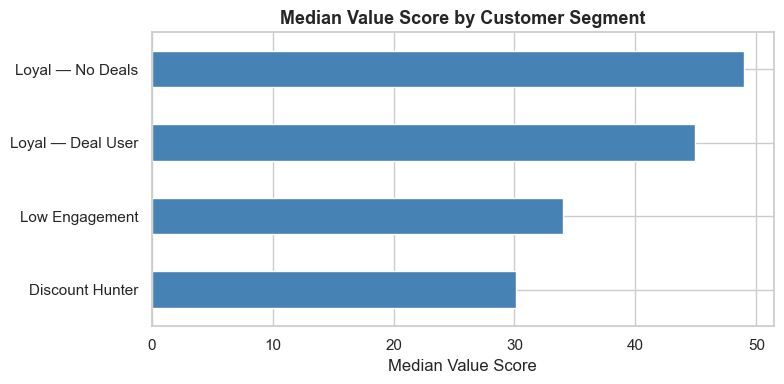

04c_score_by_segment.png Saved


In [27]:
# ── BLOCK 4.3 — Median Score by Segment ──────────────────────────────────────
# Merge segment back into score df
dfc_score["Segment"] = dfc["Segment"]

score_43 = dfc_score.groupby("Segment")["Value Score"].median().sort_values()

score_43.plot(kind='barh', figsize=(8, 4), color='steelblue', edgecolor='white')
plt.title("Median Value Score by Customer Segment", fontsize=13, fontweight='bold')
plt.xlabel("Median Value Score")
plt.ylabel("")
plt.tight_layout()
save_plot("04c_score_by_segment")

In [28]:
dfc.head(5)

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases,Segment,Age Group
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Bi-Weekly,Discount Hunter,46-55
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Bi-Weekly,Discount Hunter,18-25
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly,Loyal — Deal User,46-55
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly,Loyal — Deal User,18-25
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually,Loyal — Deal User,36-45


In [29]:
# Build final export dataframe
customer_export = dfc[["Customer ID", "Age", "Gender", "Location", 
                         "Category", "Frequency of Purchases",
                         "Subscription Status", "Payment Method",
                         "Purchase Amount (USD)", "Previous Purchases",
                         "Review Rating", "Promo Code Used", 
                         "Discount Applied", "Season",
                         "Age Group", "Segment"]].copy()

# Add value score from dfc_score
customer_export["Value Score"] = dfc_score["Value Score"].values

# Export
customer_export.to_csv("customer_scores_final.csv", index=False)
print(f"Exported {len(customer_export)} rows")
print(customer_export.head())

Exported 3900 rows
   Customer ID  Age Gender       Location  Category Frequency of Purchases  \
0            1   55   Male       Kentucky  Clothing              Bi-Weekly   
1            2   19   Male          Maine  Clothing              Bi-Weekly   
2            3   50   Male  Massachusetts  Clothing                 Weekly   
3            4   21   Male   Rhode Island  Footwear                 Weekly   
4            5   45   Male         Oregon  Clothing               Annually   

  Subscription Status Payment Method  Purchase Amount (USD)  \
0                 Yes          Venmo                     53   
1                 Yes           Cash                     64   
2                 Yes    Credit Card                     73   
3                 Yes         PayPal                     90   
4                 Yes         PayPal                     49   

   Previous Purchases  Review Rating Promo Code Used Discount Applied  Season  \
0                  14            3.1             Yes